# Analyzing 2024 U.S. Presidential Voting Patterns
#### Spring 2026 Data Science Project
#### By: James Hawkins, Jason Yu, Enyu Liang, Akhil Shashtry

Contributions:

James:
- Project/Dataset Idea
- Exploratory Data Analysis Conclusion 1
- Machine Learning Analysis and Interpretations/Recommendations
- Data Curation for EDA and ML Analysis

Jason:
- Final Submission Data Curation Formatting and Compilation
- Exploratory Data Analysis Conclusion 4
- Final Submission Introduction Section
- Final Submission Github Page Formatting and Setup

Enyu:
- Exploratory Data Analysis Conclusion 3
- Final Submission Compilation

Akhil:
- Exploratory Data Analysis Conclusion 2
- Final Submission Compilation

**Introduction:** The purpose of this analysis is to recognize and identify several key factors that were present in the 2024 U.S. Presidential Election in influencing the vote through the ANES Pre and Post-Election surveys. When examining such a dynamic and volatile environment, it is important to remain as holistic and impartial as possible in order to obtain a more comphrensive result and predictor. There is no singular value that can be used to predict a citizen's candidate choice, thus it is important for this tutorial to view several patterns and combine various factors' analysis together.

The primary question this tutorial seeks to answer is which factors are prevalent and important in determining the sociopolitical trends in the United States at a national level. Throughout this tutorial, we will aim to examine the information presented in the ANES survey and uncover as many predictors for voting patterns as possible. Understanding which values and attributes are important to the American people can be key in assessing how the political landscape of the U.S. is changing in contemporary times from a data-driven standpoint.



#### **Data Curation:**

The data for this analysis was taken from the ANES 2024 Time Series Study

This source was assembled as a result of both pre and post election surveys of a randomly sampled group on the individual's personal attributes and beliefs alongside their presidential and political preferences. The information was collected through a variety of methods including web-based, paper and pen, face-to-face, and other methods.

Citation: American National Election Studies. 2025. ANES 2024 Time Series Study Full Release [dataset and documentation]. August 8, 2025 version. [www.electionstudies.org/data-center/2024-time-series-study/](https://electionstudies.org/data-center/2024-time-series-study/)

In this section, we will parse through the American National Election Survey Dataset and examine the cross-categorical relationship between a voter's racial group and their preferred candidate in the 2024 Presidential Election.

In [387]:
# Import libraries
import pandas as pd
import scipy as sp
import numpy as np
from matplotlib import pyplot as plt
from wcorr import WeightedCorr

# suppress DtypeWarnings when importing mixed type dataframes
import warnings
warnings.filterwarnings('ignore', category=pd.errors.DtypeWarning)

In [388]:
# Loading in the dataset

anes2024_csv = "../../dataset/data_2024/anes_timeseries_2024_csv_20250808.csv"
df2024 = pd.read_csv(anes2024_csv)

# Select relevant variables (per the Codebook)
df2024_select = df2024[["V241501x", "V241567x", "V241566x", "V241039", "V240108a",
                        "V240002c", "V242067"]]
df2024_select

,V241501x,V241567x,V241566x,V241039,V240108a,V240002c,V242067
0,3,5,27,-1,0.809064,2,2
1,4,5,26,-1,2.575472,2,-1
2,1,5,24,-1,0.798864,2,1
3,4,3,12,-1,0.244757,2,-1
4,1,3,15,-1,0.239209,2,2
...,...,...,...,...,...,...,...
5516,-8,2,5,-1,0.19183,1,-6
5517,1,3,16,-1,2.869063,2,1
5518,2,3,12,-9,2.092296,1,-6
5519,2,4,19,-1,2.826738,2,1


In [389]:
# Dictionaries for conversion

race_dict = { # V241501x
    -9: "Refused",
    -8: "Don’t Know",
    -4: "Error",
    1: "White", #"White, non-Hispanic",
    2: "Black", #"Black, non-Hispanic",
    3: "Hispanic",
    4: "Asian/Pacific-Islander", #"Asian or Native Hawaiian/other Pacific Islander, non-Hispanic",
    5: "Native American/Other", #"Native American/Alaska Native or other race, non-Hispanic",
    6: "Multiple Races", #"Multiple races, non-Hispanic",
}

president_dict = { # V242067
    -9: "Refused",
    -1: "Inapplicable",
    1: "Harris", #"Kamala Harris",
    2: "Trump", #"Donald Trump",
    3: "RFK Jr.", #"Robert F. Kennedy, Jr.",
    4: "West", #"Cornel West",
    5: "Stein", #"Jill Stein",
    6: "Other", #"Another candidate {SPECIFY}"
}

complete_survey_dict = { # V240002c
    1: 0,
    2: 1
}

In [390]:
# Making the dataset more readable
df2024_select["Race"] = df2024_select["V241501x"].map(race_dict)
df2024_select["President Vote"] = df2024_select["V242067"].map(president_dict)
df2024_select["Completed Survey"] = df2024_select["V240002c"].map(complete_survey_dict)

# Clean up 'Weights': replace empty strings with 0.
df2024_select["Weights"] = df2024_select["V240108a"]
df2024_select["Weights"] = df2024_select["Weights"].apply(lambda x: 0 if x == ' ' or x == '' else x)
df2024_select["Weights"] = df2024_select["Weights"].astype(float)

df2024_clean = df2024_select[["Race", "President Vote",
                              "Completed Survey", "Weights"]]

df2024_clean

,Race,President Vote,Completed Survey,Weights
0,Hispanic,Trump,1,0.809064
1,Asian/Pacific-Islander,Inapplicable,1,2.575472
2,White,Harris,1,0.798864
3,Asian/Pacific-Islander,Inapplicable,1,0.244757
4,White,Trump,1,0.239209
...,...,...,...,...
5516,Don’t Know,NaN,0,0.191830
5517,White,Harris,1,2.869063
5518,Black,NaN,0,2.092296
5519,Black,Harris,1,2.826738


In [391]:
# Dealing with missing values
df2024_clean.dropna()
df2024_clean

# Get only those who completed the post-election survey
df2024_relevant = df2024_clean[df2024_clean["Completed Survey"] == 1]

df2024_relevant

,Race,President Vote,Completed Survey,Weights
0,Hispanic,Trump,1,0.809064
1,Asian/Pacific-Islander,Inapplicable,1,2.575472
2,White,Harris,1,0.798864
3,Asian/Pacific-Islander,Inapplicable,1,0.244757
4,White,Trump,1,0.239209
...,...,...,...,...
5514,White,Inapplicable,1,0.797417
5515,Hispanic,Harris,1,0.129755
5517,White,Harris,1,2.869063
5519,Black,Harris,1,2.826738


The columns that I used below are, V241458x (age of voter on election day), V242067 (who the person voted for), V240002c (Pre/Post Interview Completion Status) to get data on those who filled out the information after the election, and V240108b (sampling weights per row) is needed to perform the statistical tests seen later on.

In [392]:
# Changed the names of each of the columns 

df_select = df2024[["V241458x", "V242067", "V240002c", "V240108b"]]

df_select = df_select.rename(columns={
    "V241458x": "Age",
    "V242067": "President Vote",
    "V240002c": "Completed Post Survey",
    "V240108b": "Weights"
})

df_select

,Age,President Vote,Completed Post Survey,Weights
0,50,2,2,.780974621163524
1,41,-1,2,2.50707498962934
2,44,1,2,.814400897948447
3,45,-1,2,.263490124186044
4,80,2,2,.216673241876399
...,...,...,...,...
5516,-2,-6,1,
5517,69,1,2,1.90730910362323
5518,-2,-6,1,
5519,28,1,2,2.56436072555069


In [393]:
# changed the numbers that represent each "President Vote" to the name of said president 

president_dict = { # V242067
    -9: "Refused",
    -1: "Inapplicable",
    1: "Harris", #"Kamala Harris",
    2: "Trump", #"Donald Trump",
    3: "RFK Jr.", #"Robert F. Kennedy, Jr.",
    4: "West", #"Cornel West",
    5: "Stein", #"Jill Stein",
    6: "Other", #"Another candidate {SPECIFY}"
}
df_select["President Vote"] = df2024["V242067"].map(president_dict)

# empty weight values represented as 0
df_select["Weights"] = df_select["Weights"].apply(lambda x: 0 if x == ' ' or x == '' else x)
df_select["Weights"] = df_select["Weights"].astype(float)

# remove ages below 18 years old
df_select = df_select[df_select["Age"] >= 18]

df_select

,Age,President Vote,Completed Post Survey,Weights
0,50,Trump,2,0.780975
1,41,Inapplicable,2,2.507075
2,44,Harris,2,0.814401
3,45,Inapplicable,2,0.263490
4,80,Trump,2,0.216673
...,...,...,...,...
5514,42,Inapplicable,2,0.596674
5515,80,Harris,2,0.094869
5517,69,Harris,2,1.907309
5519,28,Harris,2,2.564361


In [394]:
# drop missing values 
df_select = df_select.dropna()

# only keep data points where people finished the post survey
df_select = df_select[df_select["Completed Post Survey"] == 2]

# remove inapplicable or refused rows of people who didn't pick a candidate
df_select = df_select[df_select["President Vote"].isin(["Harris", "Trump", "West", "Stein", "Other"])]

df_select

,Age,President Vote,Completed Post Survey,Weights
0,50,Trump,2,0.780975
2,44,Harris,2,0.814401
4,80,Trump,2,0.216673
6,41,Trump,2,0.292916
10,59,Harris,2,0.964122
...,...,...,...,...
5507,45,Other,2,3.252915
5515,80,Harris,2,0.094869
5517,69,Harris,2,1.907309
5519,28,Harris,2,2.564361


Important columns:
- V240001: 2024 Time Series Case ID
- V240002c: Pre & Post Interview Completion Status
- V240108b: Full Post-Election Survey Weights - Note: The ANES Guidebook instructs that post-survey weights be used whenever there is any post-survey data
- V241012: PRE: IS R REGISTERED TO VOTE
- V241221: PRE: PARTY ID: DOES R THINK OF SELF AS DEMOCRAT, REPUBLICAN, OR INDEPENDENT
- V242066: POST: DID R VOTE FOR PRESIDENT
- V242067: POST: FOR WHOM DID R VOTE FOR PRESIDENT

This section seeks to find patterns in the relationship between registered voters' self-identified political affiliation, and the level of voter turnout for each corresponding identity. The specific candidate for which the respondent voted will not be considered.

In [395]:
# Load dataset
df2024e_select = df2024[["V240001", "V240002c", "V240108b", "V241012", "V241221", "V242066"]]
df2024e_select

,V240001,V240002c,V240108b,V241012,V241221,V242066
0,140001,2,.780974621163524,1,2,1
1,140002,2,2.50707498962934,1,5,-1
2,140003,2,.814400897948447,1,1,1
3,140004,2,.263490124186044,1,2,-1
4,140005,2,.216673241876399,1,3,1
...,...,...,...,...,...,...
5516,399764,1,,1,-8,-6
5517,399815,2,1.90730910362323,1,1,1
5518,399830,1,,1,3,-6
5519,399841,2,2.56436072555069,1,1,1


In [396]:
# Dictionaries for conversion

# V240001 will not be converted as it is the entry IDs

# V241221 - Identified Political Party
party_dict = {
    -9: "Refused",
    -8: "Don't Know",
    -1: "Inapplicable",
    0: "No Preference",
    1: "Democrat",
    2: "Republican",
    4: "Independent",
    5: "Other"
}

#V241012 - Was R registered
registered_dict = {
    -9: "Refused",
    -8: "Don't Know",
    -1: "Inapplicable",
    1: "Yes",
    2: "No",
}

#V242066 - Did R vote for President
voted_dict = {
    -7: "Insufficient Partial",
    -6: "No Post Interview",
    -1: "Inapplicable",
    1: "Yes",
    2: "No"
}

# V240002c (survey completion) already covered above as complete_survey_dict

In [397]:
# Making the dataset more readable
df2024e_select["ID"] = df2024e_select["V240001"]
df2024e_select["Registration"] = df2024e_select["V241012"].map(registered_dict)
df2024e_select["Party ID"] = df2024e_select["V241221"].map(party_dict)
df2024e_select["Voted for President"] = df2024e_select["V242066"].map(voted_dict)
df2024e_select["Completed Survey"] = df2024e_select["V240002c"].map(complete_survey_dict)

# Clean up 'Weights': replace empty strings with 0.
df2024e_select["Weights"] = df2024e_select["V240108b"]
df2024e_select["Weights"] = df2024e_select["Weights"].apply(lambda x: 0 if x == ' ' or x == '' else x)
df2024e_select["Weights"] = df2024e_select["Weights"].astype(float)

df2024e_clean = df2024e_select[["ID", "Completed Survey", "Registration", "Party ID",
                              "Voted for President", "Weights"]]

#Remove entries with NaN
df2024e_clean = df2024e_clean.dropna()

df2024e_clean

,ID,Completed Survey,Registration,Party ID,Voted for President,Weights
0,140001,1,Yes,Republican,Yes,0.780975
1,140002,1,Yes,Other,Inapplicable,2.507075
2,140003,1,Yes,Democrat,Yes,0.814401
3,140004,1,Yes,Republican,Inapplicable,0.263490
7,140008,1,No,Republican,Inapplicable,0.618924
...,...,...,...,...,...,...
5515,399579,1,Yes,Other,Yes,0.094869
5516,399764,0,Yes,Don't Know,No Post Interview,0.000000
5517,399815,1,Yes,Democrat,Yes,1.907309
5519,399841,1,Yes,Democrat,Yes,2.564361


In [398]:
# Select only entries that completed both pre- and post- survey
df2024e_relevant = df2024e_clean[df2024e_clean["Completed Survey"] == 1]

# Drop No, Inapplicable, Don't Know Entries for voting Registration - we only want registered voters
df2024e_relevant = df2024e_relevant[~df2024e_relevant["Registration"].isin(['No', 'Don\'t Know', 'Inapplicable'])]

df2024e_relevant

,ID,Completed Survey,Registration,Party ID,Voted for President,Weights
0,140001,1,Yes,Republican,Yes,0.780975
1,140002,1,Yes,Other,Inapplicable,2.507075
2,140003,1,Yes,Democrat,Yes,0.814401
3,140004,1,Yes,Republican,Inapplicable,0.263490
9,140011,1,Yes,Democrat,Inapplicable,1.030726
...,...,...,...,...,...,...
5510,399081,1,Yes,Democrat,Inapplicable,1.953840
5515,399579,1,Yes,Other,Yes,0.094869
5517,399815,1,Yes,Democrat,Yes,1.907309
5519,399841,1,Yes,Democrat,Yes,2.564361


In [399]:
# Condense No, Inapplicable into No for Presidential Voting
def condense_negative(response):
    if response == "Inapplicable":
        return "No"
    else:
        return response
    
df2024e_relevant["Voted for President"] = df2024e_relevant["Voted for President"].apply(condense_negative)

df2024e_relevant

,ID,Completed Survey,Registration,Party ID,Voted for President,Weights
0,140001,1,Yes,Republican,Yes,0.780975
1,140002,1,Yes,Other,No,2.507075
2,140003,1,Yes,Democrat,Yes,0.814401
3,140004,1,Yes,Republican,No,0.263490
9,140011,1,Yes,Democrat,No,1.030726
...,...,...,...,...,...,...
5510,399081,1,Yes,Democrat,No,1.953840
5515,399579,1,Yes,Other,Yes,0.094869
5517,399815,1,Yes,Democrat,Yes,1.907309
5519,399841,1,Yes,Democrat,Yes,2.564361


This section aims to analyze two separate relationships between the columns V242536 (American Identity) and V241156 (Feeling Thermometer: Kamala Harris), and columns V242536 (American Identity) and V241157 (Feeling Thermometer: Donald Trump). These two relationships primarily seek to analyze the correlation and impact of nationalism and patriotism in an individual to their preferential candidate. 

Because the column associated with American Identity was conducted as a post election survey, the column V240002c (Pre/Post Interview Completion Status) is also utilized to specifically filter for interviewees who filled out the post election portion of the survey. In addition, the column V240108b, which contains the sampling weights for each row, is also important for the purposes of this analysis when performing the statistical tests.

In [400]:
df_filtered = df2024[["V240002c", "V242536", "V241156", "V241157", "V240108b"]]

df_filtered

,V240002c,V242536,V241156,V241157,V240108b
0,2,1,0,100,.780974621163524
1,2,3,50,50,2.50707498962934
2,2,5,90,0,.814400897948447
3,2,2,50,70,.263490124186044
4,2,4,5,60,.216673241876399
...,...,...,...,...,...
5516,1,-6,50,50,
5517,2,3,85,0,1.90730910362323
5518,1,-6,50,50,
5519,2,3,90,0,2.56436072555069


In [401]:
# Improving readability of the filtered dataframe by renaming the columns first
df_filtered = df_filtered.rename(columns={'V240002c': 'Completed Post Survey', 'V242536': 'American Identity', 
                                    'V241156': 'Harris Feeling Thermometer', 'V241157': 'Trump Feeling Thermometer', 'V240108b': 'Weights'})
df_filtered

# Filtering rows of the dataframe so that only those who completed the post election survey are considered
df_filtered = df_filtered[df_filtered['Completed Post Survey'] == 2]
df_filtered

# Filtering rows of the dataframe with invalid American Identity values are removed
# The guide states that any negative value indicates the interviewee did not complete this question for a variety of reasons, 
# thus those specific rows will not be considered.
df_filtered = df_filtered[df_filtered['American Identity'].isin([1, 2, 3, 4, 5])]
df_filtered

# Continuing the filter through the feeling thermometers, removing any invalid rows
# Similarly to the previous filtering, the guide states that any negative values represent unusable data and will thus be removed.
df_filtered = df_filtered[(df_filtered['Harris Feeling Thermometer'] >= 0) & (df_filtered['Trump Feeling Thermometer'] >= 0)]
df_filtered

# We can observe through the guide that the american identity values are actually originally in reverse order, with 1 being the strongest 
# identity and 5 being the weakest. For the sake of consistency for the later plots and statistical testing, it will be corrected here so that
# the higher the identity value, the more strongly the interviewee feels about their american identity.
df_filtered['American Identity'] = 6 - df_filtered['American Identity']
df_filtered

# Filling in empty weight values with 0 weight
df_filtered["Weights"] = df_filtered["Weights"].apply(lambda x: 0 if x == ' ' or x == '' else x)
df_filtered["Weights"] = df_filtered["Weights"].astype(float)
df_filtered

# Creating two separate dataframes for both Harris and Trump
df_harris_e = df_filtered[['American Identity', 'Harris Feeling Thermometer', 'Weights']]
df_trump_e = df_filtered[['American Identity', 'Trump Feeling Thermometer', 'Weights']]
display(df_harris_e)
display(df_trump_e)

,American Identity,Harris Feeling Thermometer,Weights
0,5,0,0.780975
1,3,50,2.507075
2,1,90,0.814401
3,4,50,0.263490
4,2,5,0.216673
...,...,...,...
5514,4,48,0.596674
5515,5,100,0.094869
5517,3,85,1.907309
5519,3,90,2.564361


,American Identity,Trump Feeling Thermometer,Weights
0,5,100,0.780975
1,3,50,2.507075
2,1,0,0.814401
3,4,70,0.263490
4,2,60,0.216673
...,...,...,...
5514,4,48,0.596674
5515,5,0,0.094869
5517,3,0,1.907309
5519,3,0,2.564361


In [402]:
# Split apart the two dataframes even further so that we can map the distributions between identity scores
df_trump_1 = df_trump_e[df_trump_e['American Identity'] == 1]
df_trump_2 = df_trump_e[df_trump_e['American Identity'] == 2]
df_trump_3 = df_trump_e[df_trump_e['American Identity'] == 3]
df_trump_4 = df_trump_e[df_trump_e['American Identity'] == 4]
df_trump_5 = df_trump_e[df_trump_e['American Identity'] == 5]

df_harris_1 = df_harris_e[df_harris_e['American Identity'] == 1]
df_harris_2 = df_harris_e[df_harris_e['American Identity'] == 2]
df_harris_3 = df_harris_e[df_harris_e['American Identity'] == 3]
df_harris_4 = df_harris_e[df_harris_e['American Identity'] == 4]
df_harris_5 = df_harris_e[df_harris_e['American Identity'] == 5]

#### **Exploratory Data Analysis:** 

**Pt. 1: Race versus Presidential Candidate Choice (2024)**

In [403]:
# EDA
# Cross-Tab of Race and President Choice
president_race_tab = pd.crosstab(index = df2024_relevant["Race"],
                                 columns = df2024_relevant["President Vote"],
                                 values = df2024_relevant["Weights"],
                                 aggfunc=sum, normalize="index").fillna(0)

president_race_tab_percents = president_race_tab.round(4) * 100
president_race_tab_percents

President Vote,Harris,Inapplicable,Other,Refused,Stein,Trump,West
Race,,,,,,,
Asian/Pacific-Islander,47.93,22.88,1.34,0.00,0.22,27.35,0.27
Black,62.35,29.17,1.13,0.66,0.08,6.18,0.42
Hispanic,39.23,39.40,0.66,0.45,1.55,18.52,0.19
Multiple Races,34.58,32.40,2.78,0.29,0.62,28.70,0.63
Native American/Other,23.54,44.32,4.19,0.00,0.00,27.94,0.00
Refused,20.93,25.04,0.00,9.08,0.00,44.24,0.71
White,35.47,22.56,1.45,1.15,0.49,38.78,0.09


In [404]:
# Simplifying Data to only people that answered with an actual category.
df2024_simplified = df2024_relevant[df2024_relevant["Race"] != "Refused"]

# Turn third-party candidates into one category.
def collapse_third_party(vote):
    if vote in ["West", "Stein", "Other"]:
        return "Other"
    else:
        return vote

df2024_simplified["President Vote"] = df2024_simplified["President Vote"].apply(collapse_third_party)

df2024_simplified = df2024_simplified[df2024_simplified["President Vote"] != "Refused"]
df2024_simplified = df2024_simplified[df2024_simplified["President Vote"] != "Inapplicable"]

df2024_simplified

,Race,President Vote,Completed Survey,Weights
0,Hispanic,Trump,1,0.809064
2,White,Harris,1,0.798864
4,White,Trump,1,0.239209
6,White,Trump,1,0.290135
10,White,Harris,1,0.940042
...,...,...,...,...
5507,White,Other,1,3.652063
5515,Hispanic,Harris,1,0.129755
5517,White,Harris,1,2.869063
5519,Black,Harris,1,2.826738


In [405]:
# Cross-Tab with simplified, positive voter dataset
race_president_cross_tab = pd.crosstab(index = df2024_simplified["Race"],
                                 columns = df2024_simplified["President Vote"],
                                 values = df2024_simplified["Weights"],
                                 aggfunc=sum, normalize="index").fillna(0)

race_president_cross_tab_percents = race_president_cross_tab.round(4) * 100
race_president_cross_tab_percents

President Vote,Harris,Other,Trump
Race,,,
Asian/Pacific-Islander,62.15,2.38,35.47
Black,88.87,2.33,8.80
Hispanic,65.23,3.99,30.79
Multiple Races,51.37,5.99,42.64
Native American/Other,42.28,7.53,50.19
White,46.50,2.67,50.83


<Axes: title={'center': '% 2024 Presidential Election Candidate Choice by Racial Group'}, xlabel='Race'>

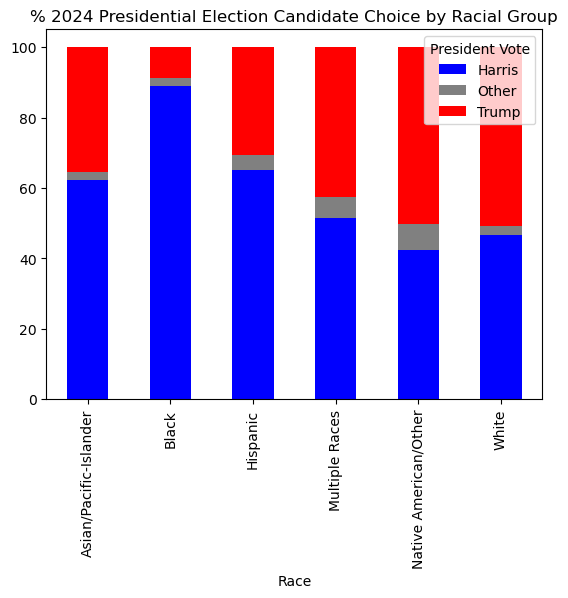

In [406]:
# Bar plot
race_v_president_barplot = race_president_cross_tab_percents.plot.bar(
    stacked = True, 
    title = "% 2024 Presidential Election Candidate Choice by Racial Group",
    color = ['blue', 'grey', 'red']
)

race_v_president_barplot

Based on this bar chart and the cross-tab, it appears that there is a difference in candidate preference across the different racial groups. Let us test this with a hypothesis:

Null Hypothesis: there is no difference in candidate preference (for the 2024 Presidential Election) across different racial groups.

Alternative Hypothesis: there is a difference in candidate preference across racial groups.


We will use a Chi^2 test to see if the above results are likely to have arisen given random chance.

In [407]:
# Chi^2 Test on this Cross-Tabulation

# We need to actually remake the cross-tab, because Chi^2 cares about counts.
race_president_cross_tab_count = pd.crosstab(index = df2024_simplified["Race"],
                                 columns = df2024_simplified["President Vote"],
                                 values = df2024_simplified["Weights"],
                                 aggfunc=sum).fillna(0)


race_president_test = sp.stats.chi2_contingency(race_president_cross_tab_count)
p_value = race_president_test.pvalue
print(f"P-Value: {float(p_value)}")

race_president_cross_tab_count
# The values in this cross-tab are floats due to weighting, but they still function as
# cross-category frequencies.

P-Value: 5.31356546152406e-54


President Vote,Harris,Other,Trump
Race,,,
Asian/Pacific-Islander,105.033297,4.014358,59.938848
Black,332.888678,8.738046,32.972940
Hispanic,256.988709,15.701025,121.302511
Multiple Races,74.991483,8.740201,62.245260
Native American/Other,4.740423,0.844645,5.627008
White,1060.584502,60.941264,1159.539760


Based on this Chi^2 test, we can conclude that there is a statistically significant difference between the frequences of votes for Harris, Trump, and other candidates based on racial group of the voter. The p-value is well less than the statistical significance threshold of alpha = 0.05

It should be noted that there are possible confounders to this relationship, namely income group and age.

Outliers here would be votes for other candidates besides Harris and Trump, which make up a substantial minority of voters.
We filtered out non-voters and people who refused to or otherwise did not answer the questions about race and who they voted for in the Presidential Election. We also (necessarily) only considered survey entries that completed the post-election survey (to indicate who they voted for).
Imbalance of demographic groups should be mitigated for by the row weights, and the ANES has assured that its samples are representative.

Based on the cross-tab, it would appear that Asians, Hispanics, and especially African Americans were more likely to vote for Harris than Trump. People of multiple races were more likely to vote for Harris than Trump, but by less of a significant margin. Whites and Native Americans were more likely to vote for Trump, but also by less of a significant margin. It should be noted that the Native American sample is small, and so is perhaps biased. Whites are well overrepresented in this dataset, with Blacks, Hispanics, and Asians being the next highest groups.

**Conclusion 2: Presidential Candidate Choice (2024) versus Age**

The Goal of this analysis is to undestand the relationship between the age of the voter and their vote choice, so we can see if there is a correlation between the two continuous variables.

EDA

First we examine the basic characteristics of the age variable across the dataset, by looking at the mean, median, standard deviation, and distribution for each candiate. 

In [408]:
print("Age Data Statistics: ")
print("----------------------")
print(df_select["Age"].describe())

Age Data Statistics: 
----------------------
count    3531.000000
mean       55.174172
std        16.769812
min        18.000000
25%        41.000000
50%        57.000000
75%        69.000000
max        80.000000
Name: Age, dtype: float64


In [409]:
print("Mean Age by Candidate: ")
print("-------------------------")
print(df_select.groupby("President Vote")["Age"].mean())

Mean Age by Candidate: 
-------------------------
President Vote
Harris    54.862300
Other     45.576923
Stein     46.090909
Trump     56.124668
West      42.200000
Name: Age, dtype: float64


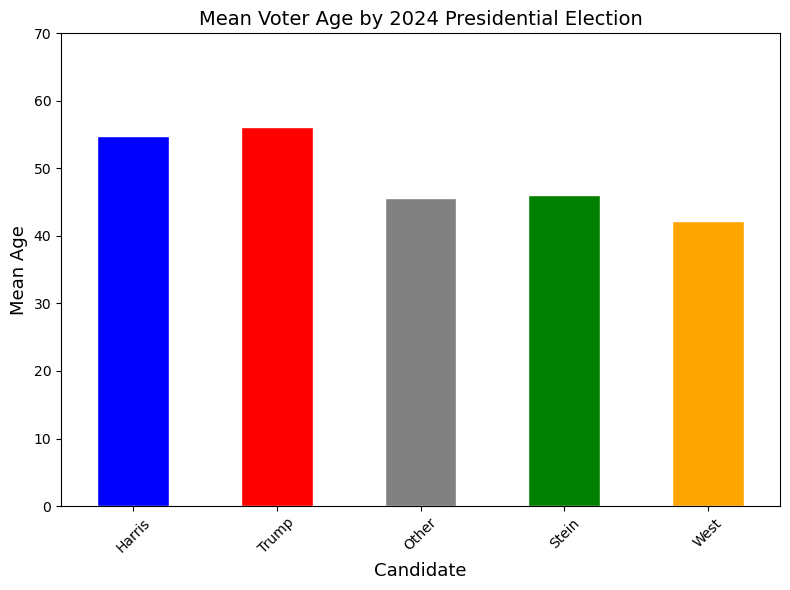

In [410]:
# A bar chart to showcase the relationship between age and candiate selection

fig, ax = plt.subplots(figsize=(8, 6))

mean_ages = df_select.groupby("President Vote")["Age"].mean().reindex(["Harris", "Trump", "Other", "Stein", "West"])

mean_ages.plot.bar(color=["blue", "red", "gray", "green", "orange", "purple"],  edgecolor="white", ax=ax, width=0.5)

ax.set_xlabel("Candidate", fontsize=13)
ax.set_ylabel("Mean Age", fontsize=13)
ax.set_title("Mean Voter Age by 2024 Presidential Election", fontsize=14)
ax.set_ylim(0, 70)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Now to better see the distribution of the ages of each candidate the variance of the data we can use a side by side boxplot.
This will allow us to exclude large or too small values which might skew the reslts

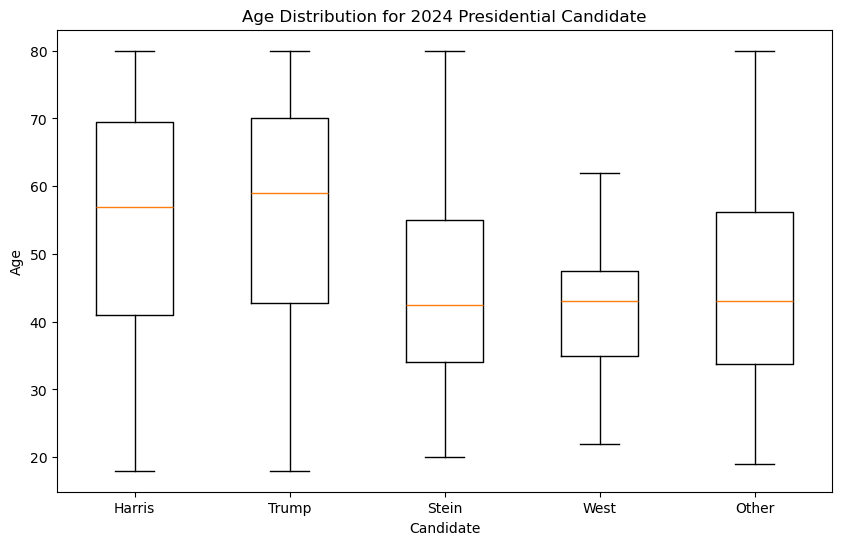

In [411]:
# split the dataset for each candiate so we can make a box plot for each one, for a side by side comparison
df_harris = df_select[df_select["President Vote"] == "Harris"]
df_trump = df_select[df_select["President Vote"] == "Trump"]
df_stein = df_select[df_select["President Vote"] == "Stein"]
df_west = df_select[df_select["President Vote"] == "West"]
df_other = df_select[df_select["President Vote"] == "Other"]

plt.figure(figsize=(10, 6))
plt.boxplot([df_harris["Age"], df_trump["Age"], df_stein["Age"], df_west["Age"], df_other["Age"]],
            tick_labels=["Harris", "Trump", "Stein", "West", "Other"])
plt.ylabel("Age")
plt.xlabel("Candidate")
plt.title("Age Distribution for 2024 Presidential Candidate")
plt.show()

Now we will do Kruskal-Wallis Hypothesis Test

H_0 (null hypothesis): The age distributions of all candidates are the same, so there is no difference in the age of who voted for each candidate.

H_1 (alternative hypothesis): At least one candidate has a significantly different age distribution than the others. 

In [412]:
stat, p_value = sp.stats.kruskal(df_harris["Age"], df_trump["Age"],  df_stein["Age"], df_west["Age"], df_other["Age"])
print(f"Kruskal-Wallis H statistic: {stat:.4f}")
print(f"P-value: {p_value:.2e}")

Kruskal-Wallis H statistic: 33.4709
P-value: 9.57e-07


In [413]:
# we will use p = 0.05 to determine whether to reject or fail to reject the null
if p_value < 0.05:
    print("Reject null hypothesis -  At least one candidate has a significantly different age distribution than the others")
else: 
    print("Fail to reject null - The age distributions of all candidates are the same")
    

Reject null hypothesis -  At least one candidate has a significantly different age distribution than the others


From this data exploration, we can see several patterns in the 
relationship between respondent age and their candidate choice.

First the descriptive stats reveal that Trump voters have the highest mean age 
at 56.1 years, followed by Harris voters at 54.9 years. Third party candidates 
tend to attract younger voters, with West voters averaging 42.2 years and Stein 
voters at 46.1 years. The overall sample has a mean age of 55.2 years, suggesting 
the dataset skews older.

The boxplots further support this trend, showing that Trump voters have the highest 
median age, followed closely by Harris voters. Third party candidates attract 
noticeably younger voters with lower medians. 

The Kruskal-Wallis test produced an H statistic of 33.47 and a p-value of 9.57e-07, 
which is far below the significance threshold of alpha = 0.05, we had chosen. We therefore 
reject the null hypothesis, that the age distributions across candidate groups are 
statistically significantly different and did not occur by chance.

Some issues to note are that third party candidates such as Stein, West, and 
Other have considerably smaller sample sizes compared to Harris and Trump, meaning 
conclusions drawn about those groups may not be as strong. Additionally, age is 
likely not the only factor influencing vote choice, as possible confounders include 
race, income, and party identification.

Nevertheless, the statistically significant result confirms that age is a 
meaningful variable in understanding 2024 presidential vote choice.

**Conclusion 3: Voter Identification versus Voter Turnout**

In [414]:
# Creating a crosstab summarization of voter turnout by party ID
voter_turnout_tab = pd.crosstab(index=df2024e_relevant['Party ID'],
            columns=df2024e_relevant['Voted for President'],
            values=df2024e_relevant['Weights'],
            aggfunc="sum"
            )

voter_turnout_tab = voter_turnout_tab.reindex(index=['Democrat', 'Republican', 'No Preference', 'Don\'t Know', 'Refused', 'Other'],
                                              columns=['Yes', 'No'])

# Simple sum of weighted values, shows relative scale of Party ID categories
print(voter_turnout_tab)

print("\n")

# Calculating ratios for each category
voter_turnout_tab_percent = pd.crosstab(index=df2024e_relevant['Party ID'],
            columns=df2024e_relevant['Voted for President'],
            values=df2024e_relevant['Weights'],
            aggfunc="sum",
            normalize="index"
            )

voter_turnout_tab_percent = voter_turnout_tab_percent.reindex(index=['Democrat', 'Republican', 'No Preference', 'Don\'t Know', 'Refused', 'Other'],
                                              columns=['Yes', 'No'])

voter_turnout_tab_percent = voter_turnout_tab_percent.round(4) * 100

print(voter_turnout_tab_percent)

Voted for President          Yes          No
Party ID                                    
Democrat             1318.877991  261.279551
Republican           1075.981712  240.182408
No Preference          11.263082    9.884599
Don't Know              1.054259    2.785557
Refused                 7.434706    3.391035
Other                  92.524240   29.443696


Voted for President    Yes     No
Party ID                         
Democrat             83.46  16.54
Republican           81.75  18.25
No Preference        53.26  46.74
Don't Know           27.46  72.54
Refused              68.68  31.32
Other                75.86  24.14


Registration        Yes
Party ID               
Democrat       0.517388
No Preference  0.006924
Republican     0.430950
Don't Know     0.001257
Other          0.039936
Refused        0.002837


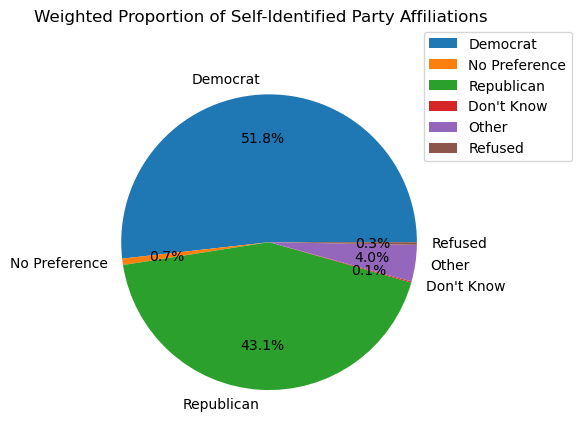

In [415]:
# Calculating ratio of Party Identifications to Overall Weighted Sum
party_ratio_tab = pd.crosstab(index=df2024e_relevant['Party ID'],
                              columns=df2024e_relevant['Registration'],
                              values=df2024e_relevant['Weights'],
                              aggfunc="sum",
                              normalize="all")
party_ratio_tab = party_ratio_tab.reindex(index=['Democrat', 'No Preference', 'Republican', 'Don\'t Know', 'Other', 'Refused'],
                                              columns=['Yes'])

print(party_ratio_tab)

party_ratio_pieplot = party_ratio_tab.plot.pie(
    subplots=True,
    title="Weighted Proportion of Self-Identified Party Affiliations",
    labeldistance=1.1,
    autopct='%1.1f%%',
    pctdistance=.7
)

plt.legend(loc='best', bbox_to_anchor=(0.9, 0.7))

Text(0, 0.5, 'Weighted Aggregate Voting')

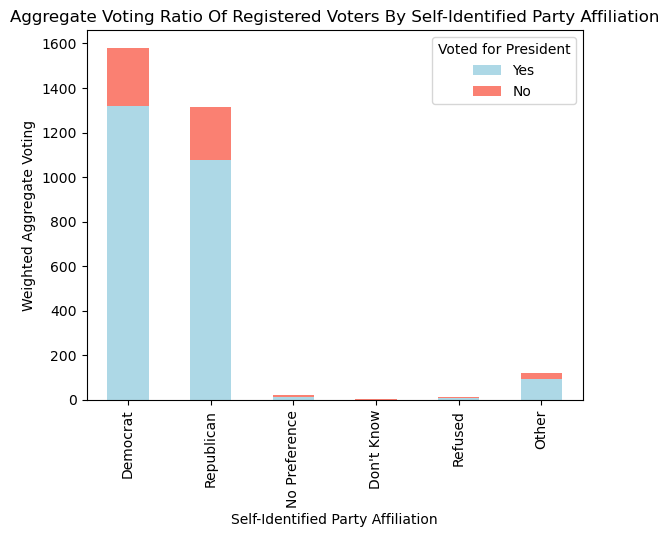

In [416]:
voter_turnout_barplot = voter_turnout_tab.plot.bar(
    stacked=True,
    title="Aggregate Voting Ratio Of Registered Voters By Self-Identified Party Affiliation",
    color=['lightblue', 'salmon']
)

voter_turnout_barplot.set_xlabel("Self-Identified Party Affiliation")
voter_turnout_barplot.set_ylabel("Weighted Aggregate Voting")

Text(0, 0.5, 'Weighted Aggregate Voting (%)')

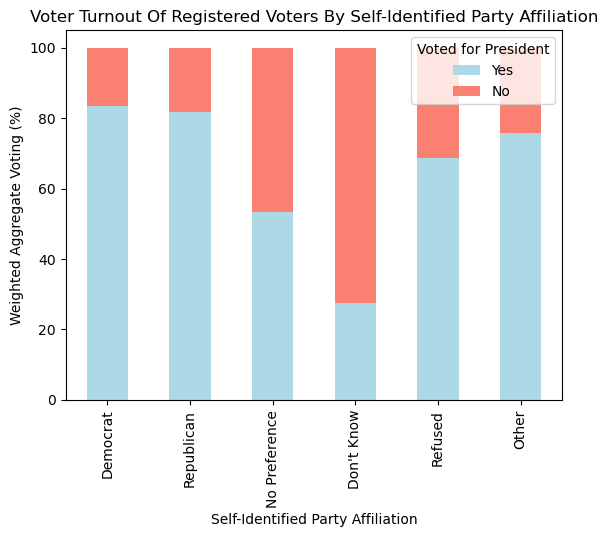

In [417]:
voter_turnout_percent_barplot = voter_turnout_tab_percent.plot.bar(
    stacked=True,
    title="Voter Turnout Of Registered Voters By Self-Identified Party Affiliation",
    color=['lightblue', 'salmon']
)

voter_turnout_percent_barplot.set_xlabel("Self-Identified Party Affiliation")
voter_turnout_percent_barplot.set_ylabel("Weighted Aggregate Voting (%)")

From this preliminary data exploration, we can see that there are several patterns within the data in relation to political party affiliation and voter turnout.

First, self-identified Democrats and Republicans have a relatively similar (weighted) voter turnout, with 83% and 81% of registered voters for each showing up to vote for President. They also make up the vast majority of registered respondents, at 52% and 43% respectively (see pie chart).

The 3rd-highest turnout rate at 76%, and 3rd-largest group, self-identified as Other, which was an open response answer. This was followed by those who Refused to answer at 69%, and those with No Preference at 53%. Finally, those who selected "Don't Know" had the lowest level of voter turnout, at just 27%.

These trends can be found to generally correspond with varying level of interest and involvement in the political process. Self-identified Democrats and Republicans were most invested in the Presidential race, while many registered voters without enough knowledge of or interest in politics to form an opinion did not end up voting.

We will test these conclusions with a hypothesis test:

Null Hypothesis: there is no difference between voter turnout between the different voter identification groups, and these observed results are due to random chance.

Alternative Hypothesis: there is a real difference in voter turnout between these different groups.

In [418]:
#Chi^2 Test for Independence with the weighted cumulative contingency table
turnout_chi2 = sp.stats.chi2_contingency(voter_turnout_tab)

print("P-value: ", turnout_chi2.pvalue)

P-value:  7.355163384547201e-05


From this Chi-squared test, we get a P-value which is well below the statistical threshold of 0.05. Therefore, we reject the null hypothesis and there is sufficient evidence to support the alternative conclusion that there is a statistically significant relationship between voters' party affiliation (or lack thereof) and their turnout.

There are a few limitations to the conclusions drawn from this data. Only respondents who completed both the pre- and post- survey and affirmed that they were registered to vote in the pre-survey were considered. The specific candidate respondents voted for was not considered, which may or may not be different from their self-identified party affiliation. Additionally, the number of respondents for the "No Preference", "Don't Know", and "Refused" categories are quite few, meaning that the conclusions drawn from them may not be as strong.

However, the characteristics of the dataset explored in this section still hold much value for considering the relationship between voter self-identification and their subsequent turnout at the election.

**Conclusion 4: American Identity versus Presidential Candidate Perceptions**

Now that we have cleaned our dataset, we can move to plot our data in order to draw some initial conclusions and observations about the relationship between American Identity and an individual's preference for Harris/Trump as presidential candidates.

We will use boxplots to graph the distributions of the feeling thermometer scores in accordance to the american identity of the interviewees.

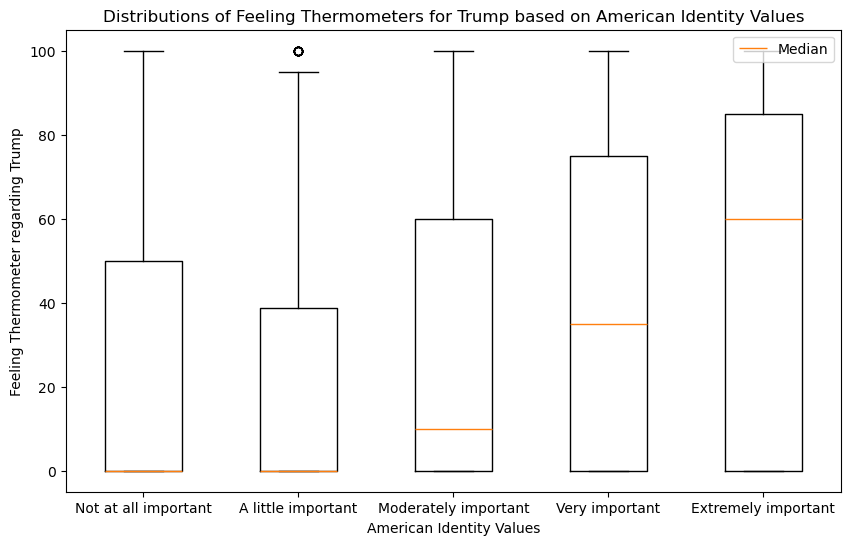

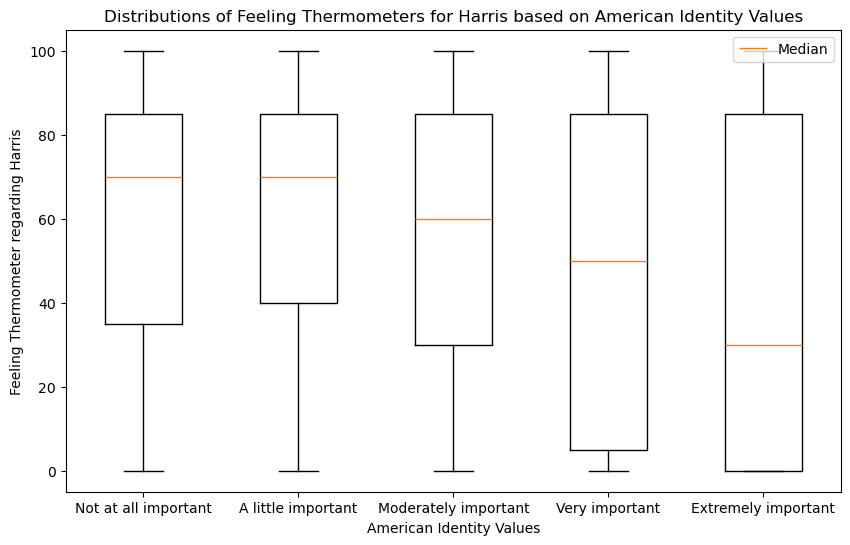

In [419]:
# Plot the newly formed dataframes into separate boxplots
plt.figure(figsize=(10, 6))
plt.boxplot([df_trump_1['Trump Feeling Thermometer'], df_trump_2['Trump Feeling Thermometer'], df_trump_3['Trump Feeling Thermometer'], df_trump_4['Trump Feeling Thermometer'], df_trump_5['Trump Feeling Thermometer']], 
            tick_labels=['Not at all important', 'A little important', 'Moderately important', 'Very important', 'Extremely important'], 
            label="Median")
plt.legend(loc='upper right')
plt.ylabel('Feeling Thermometer regarding Trump')
plt.xlabel('American Identity Values')
plt.title('Distributions of Feeling Thermometers for Trump based on American Identity Values')
plt.show()

plt.figure(figsize=(10, 6))
plt.boxplot([df_harris_1['Harris Feeling Thermometer'], df_harris_2['Harris Feeling Thermometer'], df_harris_3['Harris Feeling Thermometer'], df_harris_4['Harris Feeling Thermometer'], df_harris_5['Harris Feeling Thermometer']], 
            tick_labels=['Not at all important', 'A little important', 'Moderately important', 'Very important', 'Extremely important'], 
            label='Median')
plt.legend(loc='upper right')
plt.ylabel('Feeling Thermometer regarding Harris')
plt.xlabel('American Identity Values')
plt.title('Distributions of Feeling Thermometers for Harris based on American Identity Values')
plt.show()

In addition to these graphs, we will now perform a statistical test on the corresponding dataframes before coming to a more concrete conclusion on the relationship between an individual's American Identity and their preference for both Harris and Trump as presidential candidates.

I have chosen to use a Spearman's Correlation Coefficient test, since we have ordinal data, that being the ranking of american identity on a scale from 1 to 5, as well as a continuous variable of the feeling thermometers for both Harris and Trump. Additionally, the Spearman's Correlation Coefficient test does not depend on normality, and normality can not be assumed when it comes to the provided data for the feeling thermometers.

Hypothesis Tests: <br>
H0 = The American Identity of an individual has no effect on their feeling thermometer score for Trump/Harris <br>
HA = The American Identity of an individual has an effect on their feeling thermometer score for Trump/Harris

In [420]:
# Performing the weighted spearman's correlation coefficient tests
trump_coef = WeightedCorr(xyw=df_trump_e[['American Identity', 'Trump Feeling Thermometer', 'Weights']])(method='spearman')
harris_coef = WeightedCorr(xyw=df_harris_e[['American Identity', 'Harris Feeling Thermometer', 'Weights']])(method='spearman')

trump_unweight = sp.stats.spearmanr(df_trump_e['American Identity'], df_trump_e['Trump Feeling Thermometer'])
harris_unweight = sp.stats.spearmanr(df_harris_e['American Identity'], df_harris_e['Harris Feeling Thermometer'])

display(trump_coef)
display(harris_coef)

display(trump_unweight.pvalue)
display(harris_unweight.pvalue)

np.float64(0.2918632889626895)

np.float64(-0.20401859865017727)

np.float64(3.7270579199979215e-86)

np.float64(3.598337401231189e-43)

There are many observations that can be noted from both the statistical test and graphical plot that was created earlier regarding the relationship between american identity and the feeling thermometers of Trump and Harris.

Firstly, we can observe that our two p-values are incredibly small, much smaller than the accepted value of alpha = 0.05, we can thus reject our null hypotheses and state that the american identity of an individual has a statistical signficance on their feeling thermometer scores of Trump and Harris.

Additionally, it can be observed that there is a general positive trend in regards to an individual's american identity and their opinion of Trump. As noted by both the box plots and the spearman coefficient being greater than 0, the more an individual considers their american identity to be important to them, the higher they regard Trump as a political candidate. Inversely, a generally negative trend can be noted with american identity and the feeling thermometer score of Harris as a political candidate from the boxplots and correlation coefficient. This is seen with the median of the feeling thermometer generally decreasing as american identity grows in importance between the boxplots, as well as the corresponding spearman coefficient being less than 0.

There are still some issues that need to be discussed from these initial tests, namely the overall strength of the relationship presented for both Trump and Harris. As noted by the correlation coefficient especially, the values 0.29 and -0.20 suggest that the relationship between american identity and the feeling thermometer scores is not necessarily very strong, and in general can be stated to be moderate to weak. This suggests that while a relationship certainly does seem to exist, it might not be as prevalent as one may think and thus should be considered when performing analysis on the two variables.

These limitations can also be noticed in the boxplots as well. In every single boxplot in both graphs, one can note the clear maximum and minimum values still being from 100 to 0 respectively, thus implying that there still exist non outlier individuals in all the groups who vote out of the norm of the median. Additionally, there is a noticable "floor" effect with the Trump boxplots and a "ceiling" effect with the Harris ones, that is to say that the lower and upper quartile respectively do not seem to change as the american identity becomes increasingly important. This supports the corrleation coefficients being on the weaker side, since there are still those who vote weakly/strongly about the candidate across all the groups, thus decreasing the overall strength of the relationship between the two variables.

That being said, the indication that a relationship does exist means that these two variables are still worth analyzing and looking into for any future analysis that may come from this project.

#### **Machine Learning Analysis**

Now, we will use a machine learning method in order to do some analysis and try to uncover patterns in the ANES dataset.

Based on our exploratory data analysis, we will choose the following features in order to try and predict a voter's preferred candidate: race, household income, age group, and importance of American identity.

We will begin by compiling an appropriate dataset to pass into an ML model.

In [421]:
# Import libraries
import pandas as pd

# Loading in the dataset

anes2024_csv = "../../dataset/data_2024/anes_timeseries_2024_csv_20250808.csv"
df2024 = pd.read_csv(anes2024_csv)

df2024_select = df2024[["V241501x", "V241567x", "V241566x", "V241039", "V240108a",
                        "V240002c", "V242067", # Race, Income, Presidential Choice
                        "V241458x", # Age
                        "V242066", # Voted?
                        "V242536" # American Identity
                        ]]
df2024_select

,V241501x,V241567x,V241566x,V241039,V240108a,V240002c,V242067,V241458x,V242066,V242536
0,3,5,27,-1,0.809064,2,2,50,1,1
1,4,5,26,-1,2.575472,2,-1,41,-1,3
2,1,5,24,-1,0.798864,2,1,44,1,5
3,4,3,12,-1,0.244757,2,-1,45,-1,2
4,1,3,15,-1,0.239209,2,2,80,1,4
...,...,...,...,...,...,...,...,...,...,...
5516,-8,2,5,-1,0.19183,1,-6,-2,-6,-6
5517,1,3,16,-1,2.869063,2,1,69,1,3
5518,2,3,12,-9,2.092296,1,-6,-2,-6,-6
5519,2,4,19,-1,2.826738,2,1,28,1,3


In [422]:
# Dictionaries for conversion: we convert the ANES encoded values into readable strings.

race_dict = { # V241501x
    -9: "Refused",
    -8: "Don’t Know",
    -4: "Error",
    1: "White", #"White, non-Hispanic",
    2: "Black", #"Black, non-Hispanic",
    3: "Hispanic",
    4: "Asian/Pacific-Islander", #"Asian or Native Hawaiian/other Pacific Islander, non-Hispanic",
    5: "Native American/Other", #"Native American/Alaska Native or other race, non-Hispanic",
    6: "Multiple Races", #"Multiple races, non-Hispanic",
}

household_income_6_cat_dict = { # V241567x
    -9: "Refused",
    -5: "Break off, sufficient partial",
    -4: "Error",
    1: "<$10k", #"Under $9,999",
    2: "$10k-30k", #"$10,000 to $29,999",
    3: "$30k-60k", #"$30,000 to $59,999",
    4: "$60k-100k", #"$60,000 to $99,999",
    5: "$100k-250k", #"$100,000 to $249,999",
    6: "$250k+", #"$250,000 or more",
}

president_dict = { # V242067
    -9: "Refused",
    -1: "Inapplicable",
    1: "Harris", #"Kamala Harris",
    2: "Trump", #"Donald Trump",
    3: "RFK Jr.", #"Robert F. Kennedy, Jr.",
    4: "West", #"Cornel West",
    5: "Stein", #"Jill Stein",
    6: "Other", #"Another candidate {SPECIFY}"
}

complete_survey_dict = {
    1: 0,
    2: 1
}

#V242066 - Did R vote for President
voted_dict = {
    -7: "Insufficient Partial",
    -6: "No Post Interview",
    -1: "Inapplicable",
    1: "Yes",
    2: "No"
}

def age_group(age):
    if age < 18:
        return "Under 18"
    elif age >= 18 and age < 45:
        return "18-44"
    elif age >= 45 and age < 65:
        return "45-64"
    elif age >= 65:
        return "65 and over"
    else:
        return "Missing"
    
nationalism_dict = { # V242536
    -9: "Refused",
    -7: "Insufficient partial, interview deleted",
    -6: "No post interview",
    -5: "Sufficient partial, breakoff",
    -1: "Inapplicable",
    1: "Extremely important",
    2: "Very important",
    3: "Moderately important",
    4: "A little important",
    5: "Not at all important"
}

In [423]:
# Making the dataset more readable by applying the previous dictionaries and functions.
df2024_select["Race"] = df2024_select["V241501x"].map(race_dict)
df2024_select["Household Income"] = df2024_select["V241567x"].map(household_income_6_cat_dict)
df2024_select["President Vote"] = df2024_select["V242067"].map(president_dict)
df2024_select["Completed Survey"] = df2024_select["V240002c"].map(complete_survey_dict)
df2024_select["Voted"] = df2024_select["V242066"].map(voted_dict)
df2024_select["Age Group"] = df2024_select["V241458x"].apply(age_group)
df2024_select["American Identity"] = df2024_select["V242536"].map(nationalism_dict)

# Clean up 'Weights': replace empty strings with 0.
df2024_select["Weights"] = df2024_select["V240108a"]
df2024_select["Weights"] = df2024_select["Weights"].apply(lambda x: 0 if x == ' ' or x == '' else x)
df2024_select["Weights"] = df2024_select["Weights"].astype(float)

# Select these re-labelled columns of interest.
df2024_clean = df2024_select[["Race", "Household Income", "Age Group", "American Identity",
                              "President Vote", "Completed Survey", "Weights"]]

df2024_clean

,Race,Household Income,Age Group,American Identity,President Vote,Completed Survey,Weights
0,Hispanic,$100k-250k,45-64,Extremely important,Trump,1,0.809064
1,Asian/Pacific-Islander,$100k-250k,18-44,Moderately important,Inapplicable,1,2.575472
2,White,$100k-250k,18-44,Not at all important,Harris,1,0.798864
3,Asian/Pacific-Islander,$30k-60k,45-64,Very important,Inapplicable,1,0.244757
4,White,$30k-60k,65 and over,A little important,Trump,1,0.239209
...,...,...,...,...,...,...,...
5516,Don’t Know,$10k-30k,Under 18,No post interview,NaN,0,0.191830
5517,White,$30k-60k,65 and over,Moderately important,Harris,1,2.869063
5518,Black,$30k-60k,Under 18,No post interview,NaN,0,2.092296
5519,Black,$60k-100k,18-44,Moderately important,Harris,1,2.826738


In [424]:
# We will remove all missing values, order the orginal variables, and keep only people who 
# completed the survey (i.e. answered after the election).

# Dealing with missing values
df2024_clean.dropna()
df2024_clean

# Order variables
incomes = ["<$10k", "$10k-30k", "$30k-60k", "$60k-100k", "$100k-250k", "$250k+",
           "Refused", "Break off, sufficient partial", "Error"]
df2024_clean["Household Income"] = pd.Categorical(values = df2024_clean["Household Income"],
                                                  categories = incomes, ordered = True)
nationalism = ["Not at all important", "A little important", "Moderately important",
               "Very important", "Extremely important", "Refused", "Inapplicable",
               "No post interview", "Insufficient partial, interview deleted",
               "Sufficient partial, breakoff"]
df2024_clean["American Identity"] = pd.Categorical(values = df2024_clean["American Identity"],
                                                  categories = nationalism, ordered = True)

# Only keep people who completed the survey.
df2024_relevant = df2024_clean[df2024_clean["Completed Survey"] == 1]

df2024_relevant

,Race,Household Income,Age Group,American Identity,President Vote,Completed Survey,Weights
0,Hispanic,$100k-250k,45-64,Extremely important,Trump,1,0.809064
1,Asian/Pacific-Islander,$100k-250k,18-44,Moderately important,Inapplicable,1,2.575472
2,White,$100k-250k,18-44,Not at all important,Harris,1,0.798864
3,Asian/Pacific-Islander,$30k-60k,45-64,Very important,Inapplicable,1,0.244757
4,White,$30k-60k,65 and over,A little important,Trump,1,0.239209
...,...,...,...,...,...,...,...
5514,White,$100k-250k,18-44,Very important,Inapplicable,1,0.797417
5515,Hispanic,<$10k,65 and over,Extremely important,Harris,1,0.129755
5517,White,$30k-60k,65 and over,Moderately important,Harris,1,2.869063
5519,Black,$60k-100k,18-44,Moderately important,Harris,1,2.826738


In [425]:
# Simplifying Data: we will remove every person who gave an ambiguous category, for any variable.

df2024_simplified = df2024_relevant[df2024_relevant["Race"] != "Refused"]
df2024_simplified = df2024_simplified[df2024_simplified["Race"] != "Inapplicable"]

# Turn third-party candidates into one category.
def collapse_third_party(vote):
    if vote in ["West", "Stein", "Other"]:
        return "Other"
    else:
        return vote

df2024_simplified["President Vote"] = df2024_simplified["President Vote"].apply(collapse_third_party)

# Filter to people who answered about who the voted for.
df2024_simplified = df2024_simplified[df2024_simplified["President Vote"] != "Refused"]
df2024_simplified = df2024_simplified[df2024_simplified["President Vote"] != "Inapplicable"]

# Filter to people who answered about their income
df2024_simplified = df2024_simplified[df2024_simplified["Household Income"] != "Refused"]
df2024_simplified = df2024_simplified[df2024_simplified["Household Income"] != "Error"]
df2024_simplified = df2024_simplified[df2024_simplified["Household Income"] != "Break off, sufficient partial"]

# Filter to people who answered about their age
df2024_simplified = df2024_simplified[df2024_simplified["Age Group"] != "Missing"]

# Filter to people who answered about American Identity
df2024_simplified = df2024_simplified[df2024_simplified["American Identity"] != "Refused"]
df2024_simplified = df2024_simplified[df2024_simplified["American Identity"] != "Inapplicable"]
df2024_simplified = df2024_simplified[df2024_simplified["American Identity"] != "No post interview"]
df2024_simplified = df2024_simplified[df2024_simplified["American Identity"] != "Insufficient partial, interview deleted"]
df2024_simplified = df2024_simplified[df2024_simplified["American Identity"] != "Sufficient partial, breakoff"]


df2024_simplified = df2024_simplified[df2024_simplified["President Vote"].isna() != True]


df2024_simplified

,Race,Household Income,Age Group,American Identity,President Vote,Completed Survey,Weights
0,Hispanic,$100k-250k,45-64,Extremely important,Trump,1,0.809064
2,White,$100k-250k,18-44,Not at all important,Harris,1,0.798864
4,White,$30k-60k,65 and over,A little important,Trump,1,0.239209
6,White,$30k-60k,18-44,Moderately important,Trump,1,0.290135
10,White,$100k-250k,45-64,Moderately important,Harris,1,0.940042
...,...,...,...,...,...,...,...
5507,White,$60k-100k,45-64,Moderately important,Other,1,3.652063
5515,Hispanic,<$10k,65 and over,Extremely important,Harris,1,0.129755
5517,White,$30k-60k,65 and over,Moderately important,Harris,1,2.869063
5519,Black,$60k-100k,18-44,Moderately important,Harris,1,2.826738


In [426]:
# "Other" category for president choice may not be as important, because it is so sparse. 
# So how about we trim the dataset down to just predicting Trump/Harris, 
# and we'll use a binary encoding.

# Make the output binary.
df2024_binary = df2024_simplified[df2024_simplified["President Vote"] != "Other"]

df2024_binary["President Vote Binary"] = df2024_binary["President Vote"].apply(lambda vote:  1 if vote == "Harris" else 0)
df2024_binary

,Race,Household Income,Age Group,American Identity,President Vote,Completed Survey,Weights,President Vote Binary
0,Hispanic,$100k-250k,45-64,Extremely important,Trump,1,0.809064,0
2,White,$100k-250k,18-44,Not at all important,Harris,1,0.798864,1
4,White,$30k-60k,65 and over,A little important,Trump,1,0.239209,0
6,White,$30k-60k,18-44,Moderately important,Trump,1,0.290135,0
10,White,$100k-250k,45-64,Moderately important,Harris,1,0.940042,1
...,...,...,...,...,...,...,...,...
5506,White,$60k-100k,45-64,Extremely important,Harris,1,0.256140,1
5515,Hispanic,<$10k,65 and over,Extremely important,Harris,1,0.129755,1
5517,White,$30k-60k,65 and over,Moderately important,Harris,1,2.869063,1
5519,Black,$60k-100k,18-44,Moderately important,Harris,1,2.826738,1


We have our feature-transformed dataset ready to be fed into an ML model. Our output (voter choice) is categorical, so we will use a classification method. And because all of our features are categorical, and voters are split among many different combinations of category values, it would be most apt to try
and predict Presidential vote choice using a Decision Tree: a machine learning model that splits a dataset into successive subsets based on the most significant feature at each step, and then assigns a prediction to each of the final set of subsets.

We will specifically use the [CatBoostClassifier](https://catboost.ai/docs/en/concepts/python-reference_catboostclassifier) from the [CatBoost library](https://catboost.ai/) as our model, because (unlike a Scikit-Learn [DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)), it is able to process raw categorical/string values, which our data consists of.

In [427]:
# Import the libraries.
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt

In [428]:
# Catboost Decision Tree with binary output
seed = 42 # For determinism, because the model has a degree of randomness.

# Extract the relevant columns for the model. X is the inputted features used to predict y,
# the target. w is the weights of each row.
X = df2024_binary[["Race", "Household Income", "Age Group", "American Identity"]]
y = df2024_binary["President Vote"]
w = df2024_binary["Weights"]

# Split data into training sets and test sets. 80% will train the model, 20% will be used
# to test/evaluate it.
test_size = 0.2
Xtrain, Xtest, ytrain, ytest, wtrain, wtest = train_test_split(X, y, w, test_size=test_size,
                                                               random_state=seed, stratify=y)
# The last parameter, stratify = y, means that the data will be split so that the proportions of
# "Trump" and "Harris" voters is the same in the train and test datasets as in the overall dataset.

In [429]:
# Training the Decision Tree
categories = X.columns.tolist()
# Initialize the model
cat_dtree_bin = CatBoostClassifier(random_state=seed, cat_features=categories, verbose = 0)
# Fit it on the training data.
cat_dtree_bin.fit(Xtrain, ytrain, sample_weight=wtrain)

CatBoostClassifier(cat_features=['Race', 'Household Income', 'Age Group', 'American Identity'], random_state=42, verbose=0)

Text(0.5, 1.0, 'Test Accuracy: 0.7141612553575389')

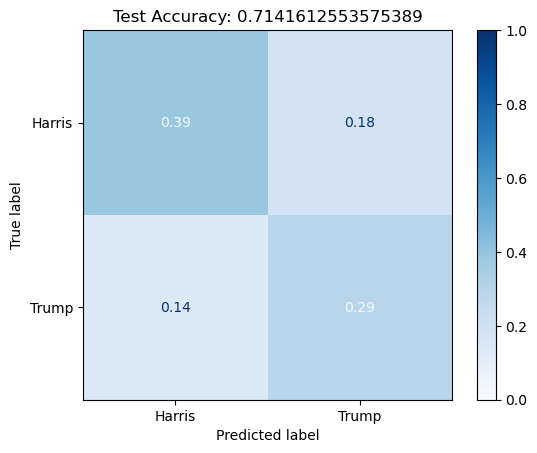

In [430]:
# Evaluation on test data: we use the model to predict the Presidential Candidate
# given the features of the test data.
y_pred = cat_dtree_bin.predict(Xtest)

# Predict the accuracy score: how many predictions were correct.
accuracy = accuracy_score(ytest, y_pred, sample_weight=wtest)

# Print the confusion matrix.
con_mat = confusion_matrix(ytest, y_pred)
con_mat = con_mat / con_mat.sum()
labels = cat_dtree_bin.classes_
plot = ConfusionMatrixDisplay(confusion_matrix=con_mat, display_labels=labels)
plot.plot(cmap = plt.cm.Blues)
plot.im_.set_clim(vmin = 0, vmax = 1)
plt.title(f"Test Accuracy: {accuracy}")

Interpretation:

This **confusion matrix** displays the proportions of correct and incorrect predictions among the test data. We can see that 39% of the model's predictions were correct predictions for Harris, 28% were correct predictions for Trump, 18% were incorrect predictions for Trump, and 15% were incorrect predictions for Harris.

The overall accuracy is about 71.3%, which is about as ideal as one can get from a dataset such as the ANES. The ANES represents real-world, social data, which is often extremely noisy and has many features. We narrowed this dataset down to four prediction features, so this model turns out to be pretty good at predicting Presidential Candidate preference with its >70% accuracy.

We'll also show the confusion matrix for the training data: it is similar to that of the testing data, so we can be confident that the model has neither underfit nor overfit on the data. It has about discovered the patterns in the data between our four selected prediction features (race, household income, age group, and American identity importance) and the target feature (Presidential vote choice).

Text(0.5, 1.0, 'Train Accuracy: 0.7231671953724389')

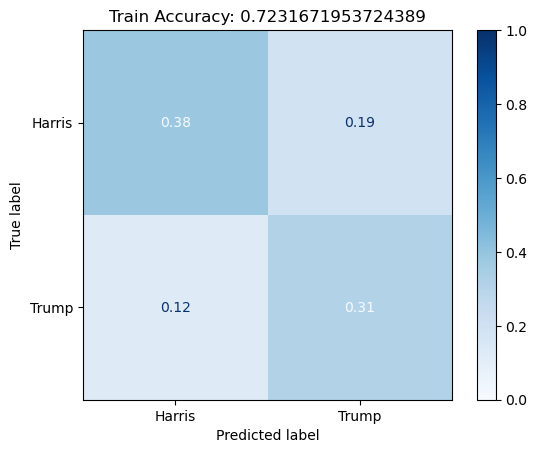

In [431]:
# Evaluation on train data.
y_pred_train = cat_dtree_bin.predict(Xtrain)

accuracy = accuracy_score(ytrain, y_pred_train, sample_weight=wtrain)

con_mat = confusion_matrix(ytrain, y_pred_train)
con_mat = con_mat / con_mat.sum()
labels = cat_dtree_bin.classes_
plot = ConfusionMatrixDisplay(confusion_matrix=con_mat, display_labels=labels)
plot.plot(cmap = plt.cm.Blues)
plot.im_.set_clim(vmin = 0, vmax = 1)
plt.title(f"Train Accuracy: {accuracy}")

We will now, in order to help our policy reccomendations, look at the model's predictions for each category of the prediction features. In order to do that, we will first format the data so we can compute the confusion matrices of each category efficiently.

We'll look just at the test data:

In [432]:
# We will go and display the confusion matrices per each result.
dfresults = Xtest.copy()
dfresults["Prediction"] = y_pred
dfresults["Actual"] = ytest
dfresults["Weight"] = wtest
dfresults

,Race,Household Income,Age Group,American Identity,Prediction,Actual,Weight
666,Hispanic,$100k-250k,18-44,Extremely important,Harris,Harris,1.479550
2738,White,$60k-100k,45-64,Very important,Trump,Trump,0.175571
2421,White,$100k-250k,45-64,Extremely important,Trump,Trump,0.640016
1111,White,$60k-100k,45-64,Very important,Trump,Harris,0.829128
4038,Multiple Races,$100k-250k,18-44,Very important,Harris,Trump,1.874986
...,...,...,...,...,...,...,...
4298,Hispanic,$30k-60k,18-44,Moderately important,Harris,Trump,0.722789
2346,White,$250k+,65 and over,Moderately important,Harris,Harris,3.250217
3685,White,$60k-100k,45-64,Moderately important,Harris,Harris,0.388935
1136,Asian/Pacific-Islander,$100k-250k,18-44,Extremely important,Trump,Trump,0.660018


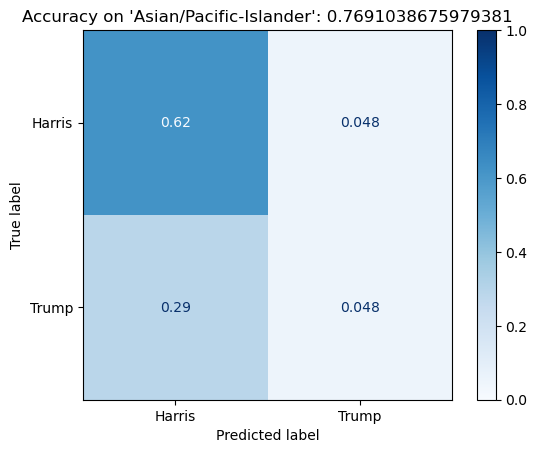

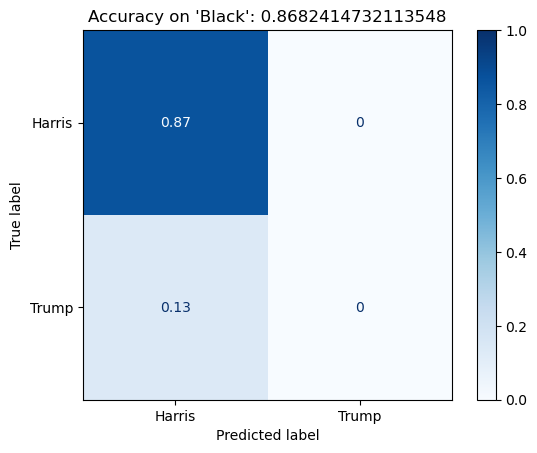

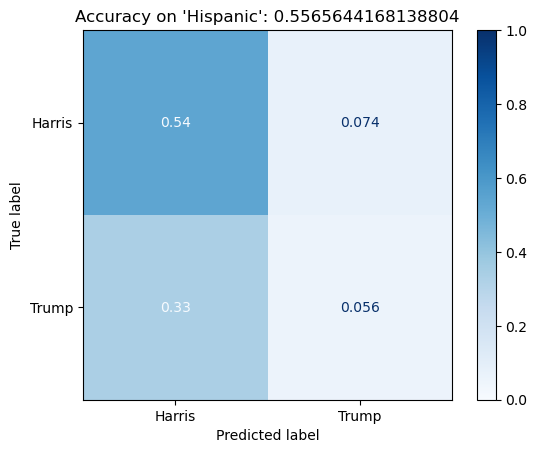

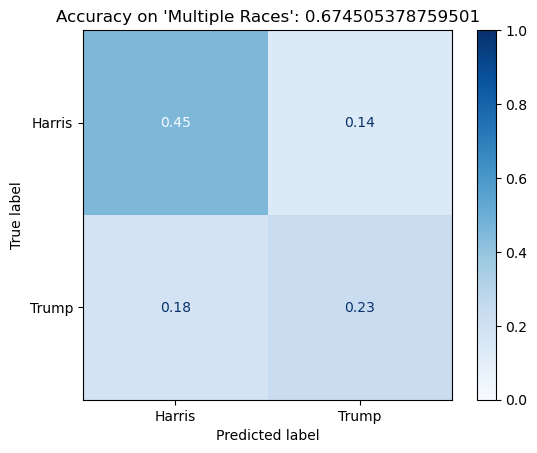

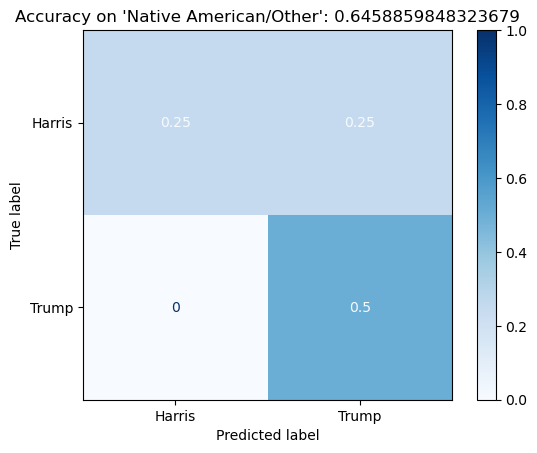

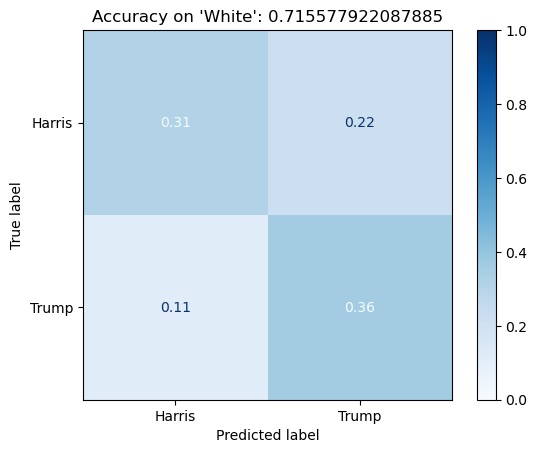

In [433]:
# Race Confusion Matrices
for race, race_df in dfresults.groupby("Race"):
    accuracy = accuracy_score(race_df["Actual"], race_df["Prediction"],
                              sample_weight=race_df["Weight"])
    title = f"Accuracy on '{race}': {accuracy}"

    con_mat = confusion_matrix(race_df["Actual"], race_df["Prediction"])
    con_mat = con_mat / con_mat.sum()
    labels = cat_dtree_bin.classes_
    plot = ConfusionMatrixDisplay(confusion_matrix=con_mat, display_labels=labels)
    plot.plot(cmap = plt.cm.Blues)
    plot.im_.set_clim(vmin = 0, vmax = 1)
    plt.title(title)

Looking at the confusion matrices for each racial group, the model does really well on predicting the votes of African-Americans (mostly for Harris) and people of multiple races (about evenly split between both candidates). It performs moderately well on Whites (about evenly split) and Asian/Pacific Islanders (about 2/3 for Harris and 1/3 for Trump, but giving most to Harris). It perform less well on Native Americans (evenly split, but giving all to Trump), and poorly on Hispanics (split between Harris and Trump, but giving most to Harris).

It would be seen that being African-American is a great predictor of votes for Harris regardless of all other values, which would suggest that the Democrats should work to maintain their appeal to this group of voters.

The race of Whites and people of multiple races do not seem to have their votes well predicted by their race, according to this model, so it seems neither party should focus on these racial groups in their campaigning.

Asians and Hispanics tend to be predicted as voting for Harris, when in actuality both racial groups actually have a larger split between both candidates (likely due to other features under consideration). Since minority groups tend to support the Democrats, the Democrats should try to analyze what is pulling these groups away from them, and the Republicans would likely be benefitted from trying to appeal to these racial groups more.

Native Americans are a small group, so the results presented by this model about this survey may not be generalizable.

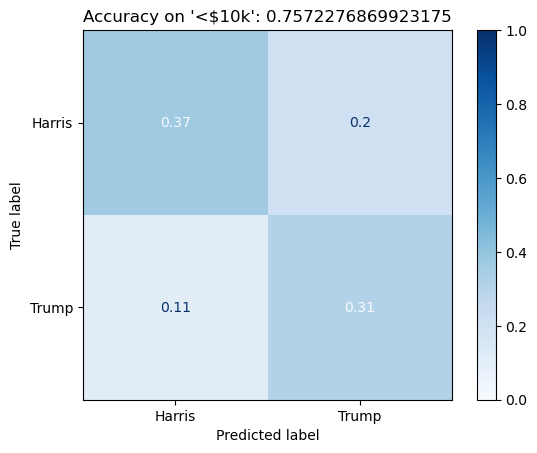

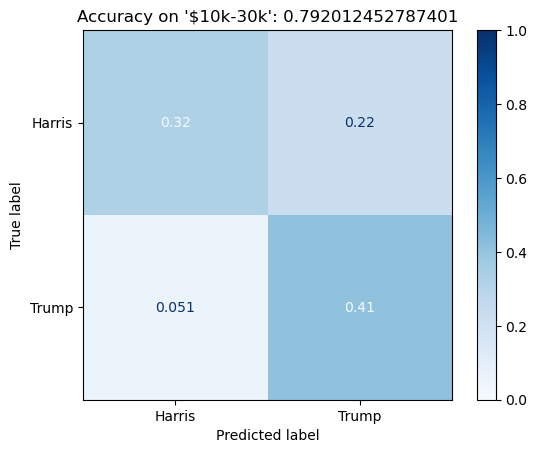

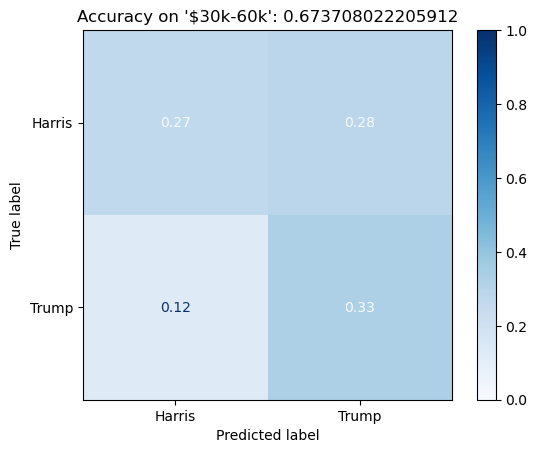

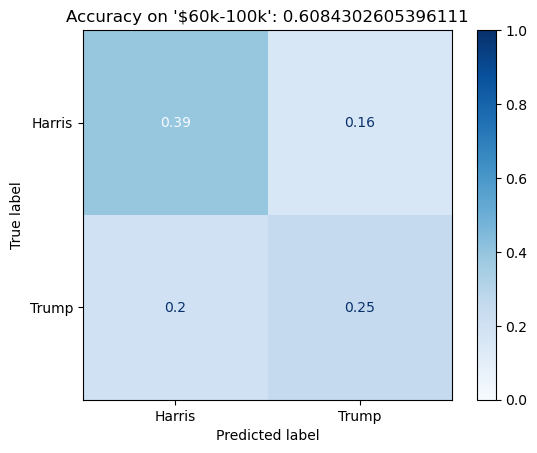

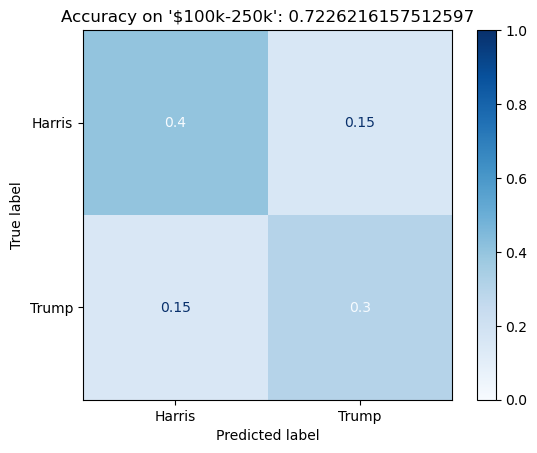

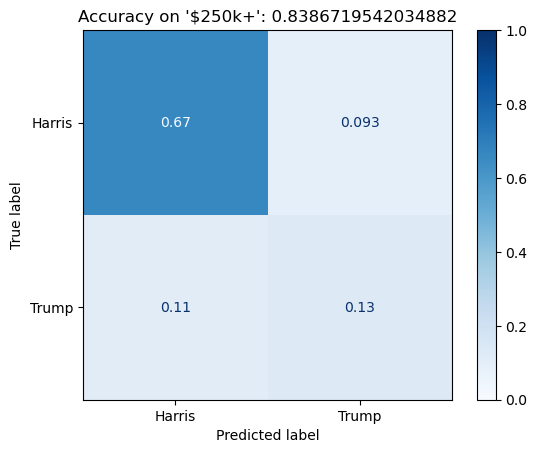

In [434]:
# Income Confusion Matrices
for income, income_df in dfresults.groupby("Household Income"):
    accuracy = accuracy_score(income_df["Actual"], income_df["Prediction"],
                              sample_weight=income_df["Weight"])
    title = f"Accuracy on '{income}': {accuracy}"

    con_mat = confusion_matrix(income_df["Actual"], income_df["Prediction"])
    con_mat = con_mat / con_mat.sum()
    labels = cat_dtree_bin.classes_
    plot = ConfusionMatrixDisplay(confusion_matrix=con_mat, display_labels=labels)
    plot.plot(cmap = plt.cm.Blues)
    plot.im_.set_clim(vmin = 0, vmax = 1)
    plt.title(title)

Looking at the confusion matrices by household income, we see that the model is only good at predicting the candidate choices of people with annual incomes higher than $250k, with about 83.9% accuracy. A strong majority of these votes also go to Kamala Harris, which would suggest that the Democrats have a broad appeal to people with high-incomes, which they should keep in mind in their campaigning.

All of the other confusion matrices show the model with moderate to high-moderate accuracy (60-77%) for all of the other income groups, and it can be seen that the model's predictions for candidate choice are about evenly split (20-40% splits in accurate predictions). This would suggest that income--for all but the highest group--are not a good predictor of Presidential candidate choice, and so both parties should not try to appeal to any group of people based merely on their income. It would seem that other factors are confounding their choices.

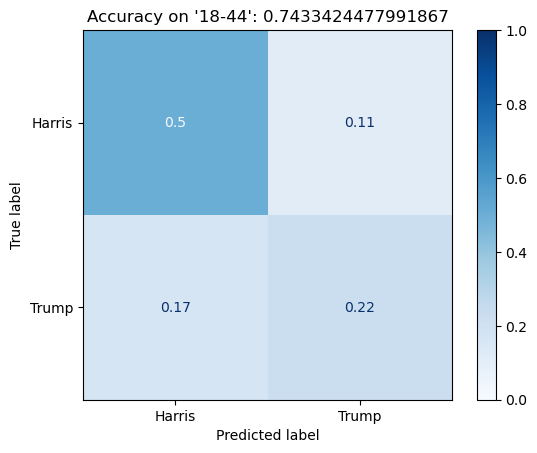

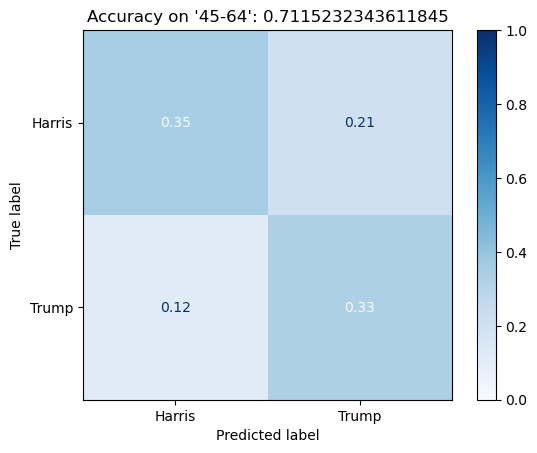

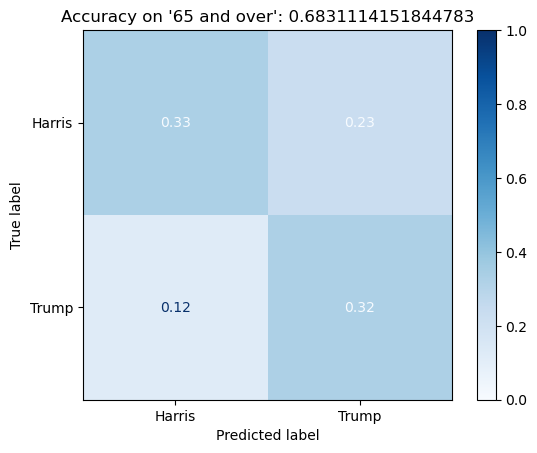

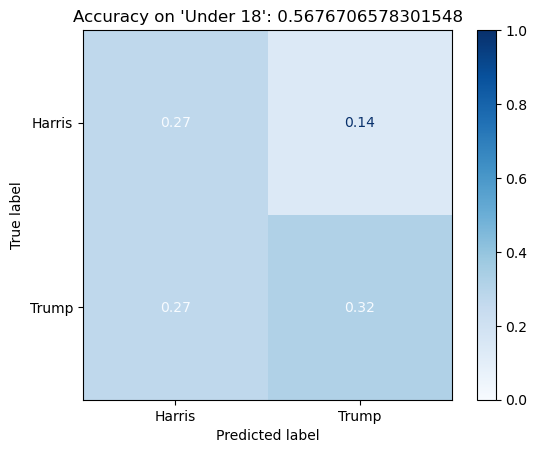

In [435]:
# Age Confusion Matrices
for age, age_df in dfresults.groupby("Age Group"):
    accuracy = accuracy_score(age_df["Actual"], age_df["Prediction"],
                              sample_weight=age_df["Weight"])
    title = f"Accuracy on '{age}': {accuracy}"

    con_mat = confusion_matrix(age_df["Actual"], age_df["Prediction"])
    con_mat = con_mat / con_mat.sum()
    labels = cat_dtree_bin.classes_
    plot = ConfusionMatrixDisplay(confusion_matrix=con_mat, display_labels=labels)
    plot.plot(cmap = plt.cm.Blues)
    plot.im_.set_clim(vmin = 0, vmax = 1)
    plt.title(title)

Looking at the confusion matrices of each age group, the model predicts candidate choice moderately well on all but the under 18 category, which would suggest that the vote choices of people under the age of eighteen years is not very predictable, given other factors. That should be kept in mind, so upcoming voters are not all that important to either party.

For the oldest two age groups, the correct predictions are about evenly split between Harris and Trump, which would suggest that people who are in the latter half of their life are just as likely to vote for either candidate, given their age. But for the group aged 18 to 44, a majority of the correct predictions are for Harris (51%), though a substantial proportion (22%) is for Trump. It would appear that it is easier to predict the vote choice of people who are younger and working-aged, and that they are more likely to choose the Democrats. The Democrats, in their campaigning, should then exploit their appeal to this group, while the Republicans should try and create an appeal to this group.

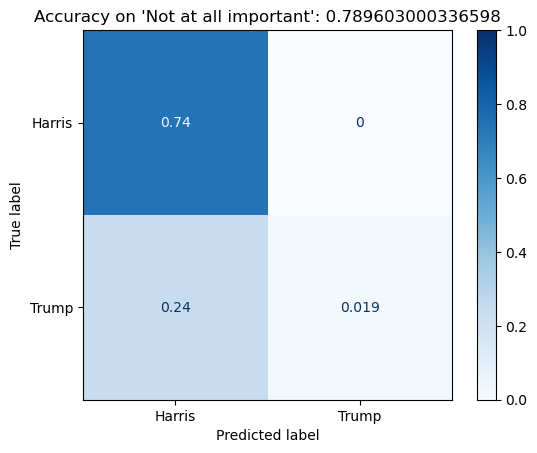

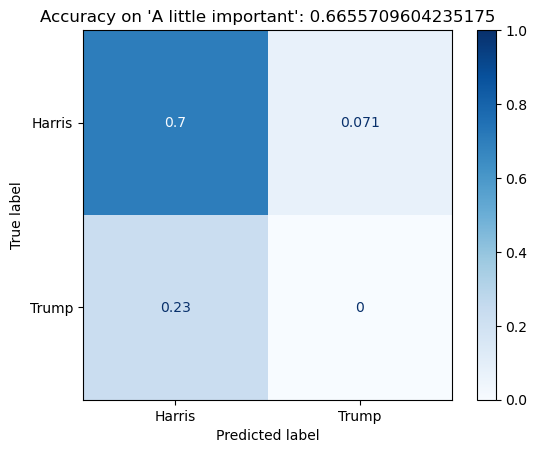

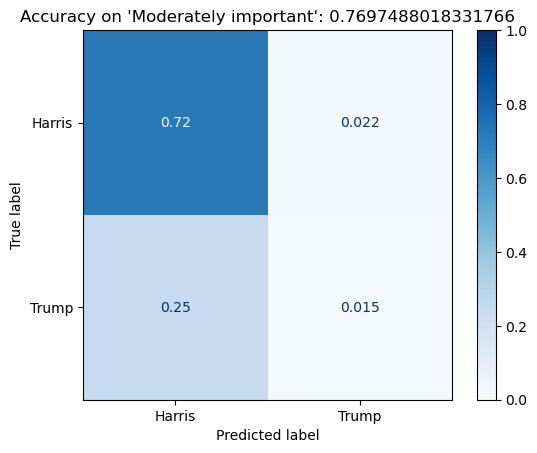

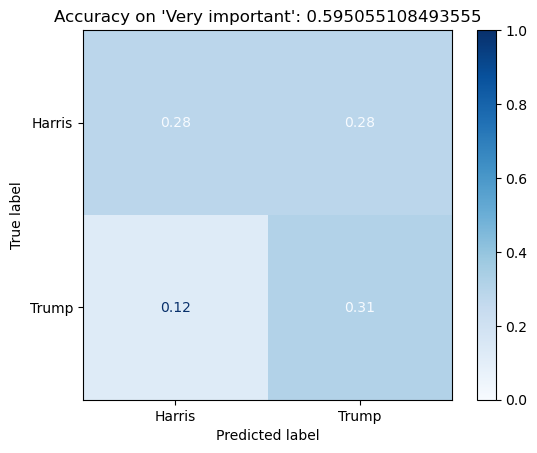

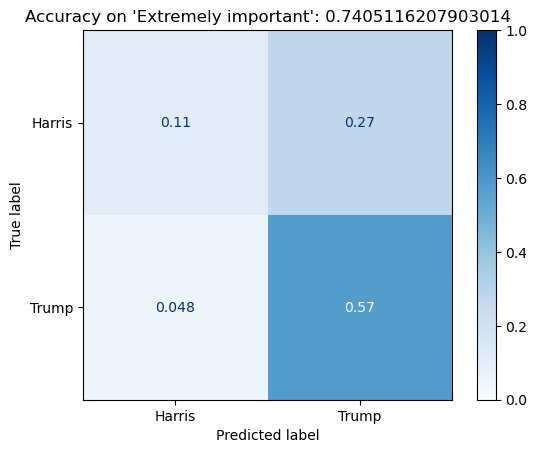

In [436]:
# Nationalism Confusion Matrices
for nation, nation_df in dfresults.groupby("American Identity"):
    accuracy = accuracy_score(nation_df["Actual"], nation_df["Prediction"],
                              sample_weight=nation_df["Weight"])
    title = f"Accuracy on '{nation}': {accuracy}"

    con_mat = confusion_matrix(nation_df["Actual"], nation_df["Prediction"])
    con_mat = con_mat / con_mat.sum()
    labels = cat_dtree_bin.classes_
    plot = ConfusionMatrixDisplay(confusion_matrix=con_mat, display_labels=labels)
    plot.plot(cmap = plt.cm.Blues)
    plot.im_.set_clim(vmin = 0, vmax = 1)
    plt.title(title)

Looking at the confusion matrices for the "American Identity" groups, the model performs fairly well at predicting the votes of people to whom being an American is "not at all important" and "moderately important", less well of people to whom it is "extremely important" and "a little important", and lower-moderately well for people to whom it is "very important".

It would appear for people who consider being an American "very important", they are about split between both candidates, and so it is not a good predictor of candidate choice. For every group lower than "very important", the model has more than 70% of the predictions being correct predictions for Harris. Meanwhile, for the group that considers being American "extremely important", 56% of the predictions are correct for Trump, and it predicts the strong majority of nationalist Americans to prefer Trump.

It would appear, based on these results, that for those to whom being an American is not so important, they are more much more likely to vote for Harris. In which case, the Democrats probably should not include too much nationalistic rhetoric in their campaigning in order to maintain touch with this voter base. Trump seems to have more strength in nationalistic circles, though, and so the Republicans can try and appeal to the people to whom being American is "very important" and try to draw them into the category that thinks it is "extremely important", which finds appeal in Republican candidates.

In summation, it would appear that:

The Democrats have stronger predictable appeal with
- African-Americans
- People of really high incomes
- People who are not so patriotic.

The Republicans have stronger predictable appeal with
- Nationalists

Traits that do not appear strongly favored to either candidate are:
- Whites, Asians, Hispanics, Mix-Raced
- Everyone below the upper class
- Middle-aged and elderly

The two parties can adjust their campaign strategies according to the likely responses of these groups: consolidate appeals among the ones likely to choose them, and try to reach out to the ones that don't have strong observed preference yet.